In [11]:
%load_ext autoreload
%autoreload 2

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from likelihoods import mapping_norm_to_scale_uniform

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

# path = '/home/hz420/python_script/SchwarMAX/'
path = '/Users/hanyuan/Dropbox/python_script/SchwarMAX/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Best-fit parameters:
logM_halo: 11.7977
logM_disk: 9.9737
logRs_halo: 1.0774
logRs_disk: 0.2746
logHs_disk: -0.1827
$\alpha$: -28.3097
$\beta$: -20.1776
$\gamma$: -7.6037


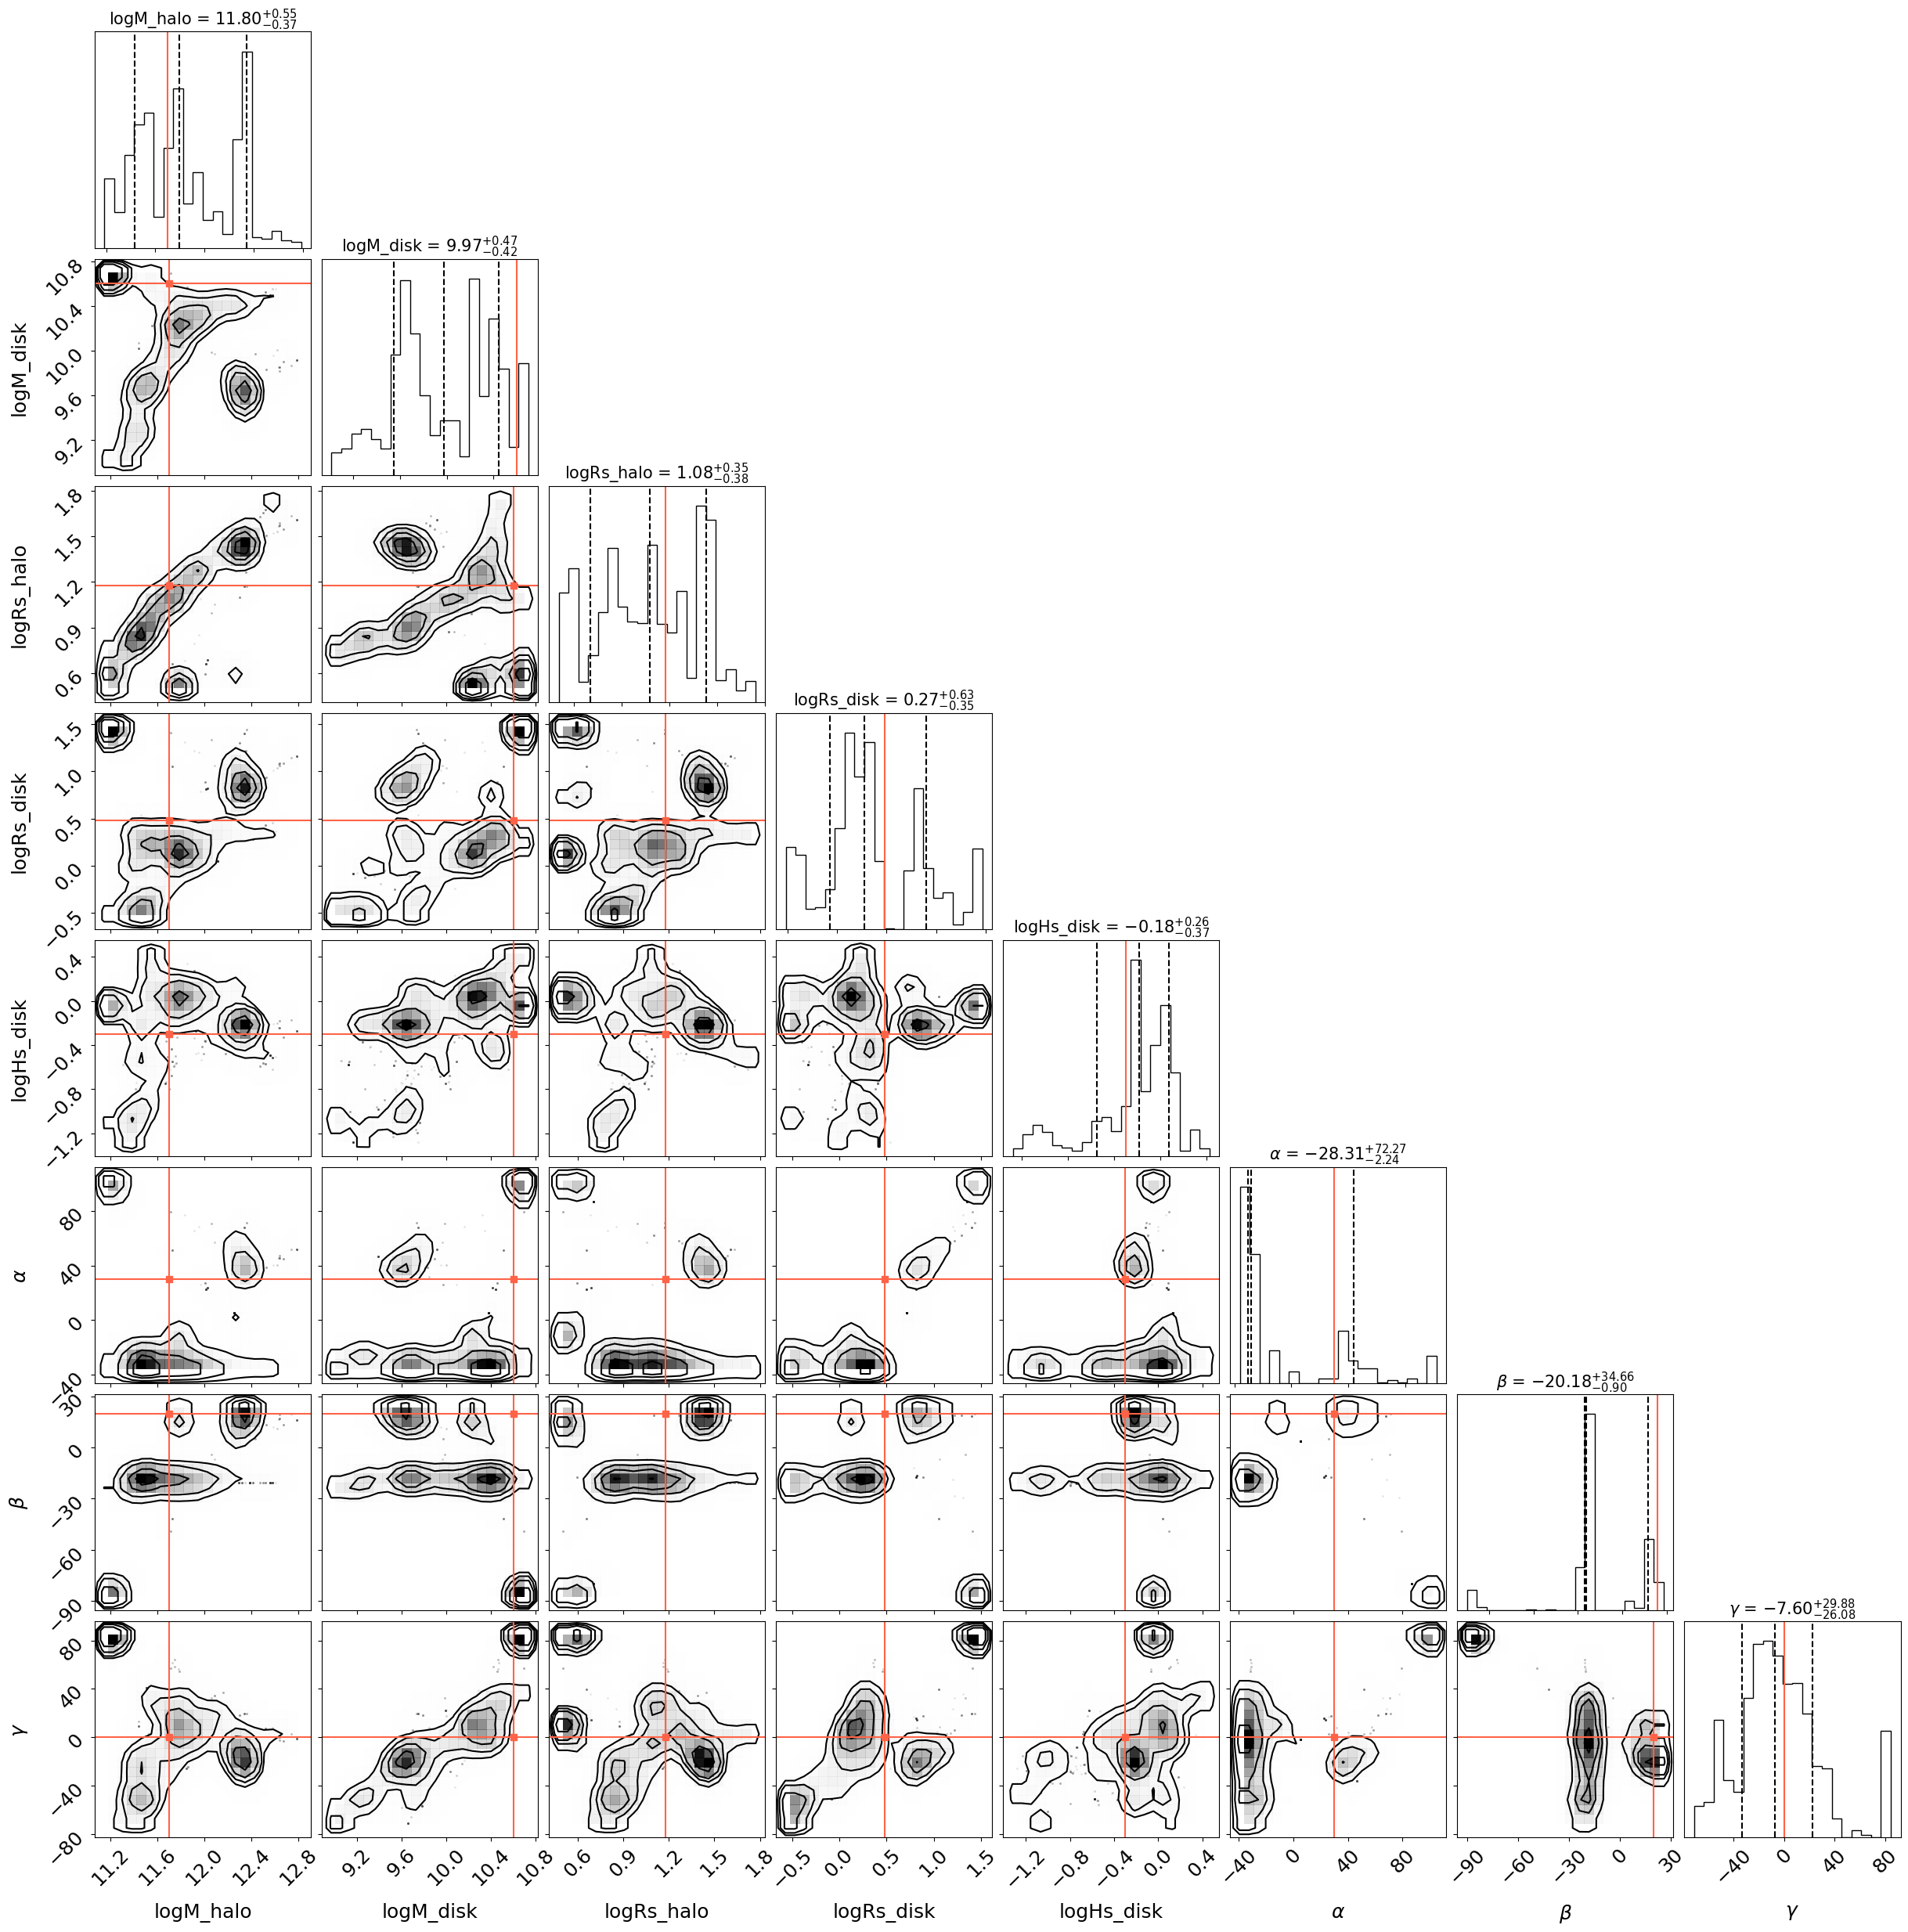

In [90]:
import pandas as pd
import corner


param_names = ['logM_halo', 'logM_disk', 'logRs_halo', 'logRs_disk', 'logHs_disk', r'$\alpha$', r'$\beta$', r'$\gamma$']

PATH_DATA = path
with open(PATH_DATA + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

with open(PATH_DATA + '/mock_axisymmetric_disc_XY_withRot.pkl', 'rb') as f:
    mock_data = pickle.load(f)

ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
        r'$\alpha$': mock_data['orientation'][0],
        r'$\beta$': mock_data['orientation'][1],
        r'$\gamma$': mock_data['orientation'][2],
}


data_folder = '/Users/hanyuan/Desktop/PhD_projects/SchwarMAX_data'
fig, ax = plt.subplots(8, 8, figsize=(25, 25))
posterior = pd.read_csv(data_folder + '/test_posterior_0210.csv').to_numpy()

# logRs_halo = mapping_norm_to_scale_uniform(posterior[:,2], posterior[:,3], min=0.5, max=1.5)
# logRs_disk = mapping_norm_to_scale_uniform(posterior[:,4], posterior[:,5], min=0., max=1.0)
# logHs_disk = mapping_norm_to_scale_uniform(posterior[:,6], posterior[:,7], min=-1.0, max=0.)
# alpha = np.arctan2(posterior[:,3], posterior[:,2])
# beta = np.arctan2(posterior[:,5], posterior[:,4])
# gamma = np.arctan2(posterior[:,7], posterior[:,6])


# samples_plot = np.zeros((posterior.shape[0], len(param_names)))
# samples_plot[:,0] = posterior[:,0]
# samples_plot[:,1] = posterior[:,1]
# samples_plot[:,2] = logRs_halo
# samples_plot[:,3] = logRs_disk
# samples_plot[:,4] = logHs_disk
# samples_plot[:,5] = alpha * 180/np.pi
# samples_plot[:,6] = beta * 180/np.pi
# samples_plot[:,7] = gamma * 180/np.pi

samples_plot = np.zeros((posterior.shape[0], len(param_names)))
samples_plot[:,0] = posterior[:,0]
samples_plot[:,1] = posterior[:,1]
samples_plot[:,2] = posterior[:,2]
samples_plot[:,3] = posterior[:,3]
samples_plot[:,4] = posterior[:,4]
samples_plot[:,5] = posterior[:,5] * 180/np.pi
samples_plot[:,6] = posterior[:,6] * 180/np.pi
samples_plot[:,7] = posterior[:,7] * 180/np.pi


ground_truth_plot = [ground_truth[k] for k in param_names]
corner.corner(samples_plot, labels=param_names, truths=ground_truth_plot, 
              show_titles=True, title_fmt='.2f', title_kwargs={"fontsize": 15},
              smooth=True, truth_color='tomato', quantiles=[0.16, 0.5, 0.84], fig=fig)

best_fit_param = np.percentile(samples_plot, 50, axis=0)
print("Best-fit parameters:")
for i, name in enumerate(param_names):
    print(f"{name}: {best_fit_param[i]:.4f}")

# fig.savefig('/data/hz420-2/SchwarMAX/plots/Mock_axisymmetric_disc_posterior_0204.png', dpi=300)
# plt.show()

Best-fit parameters:
logM_halo: 12.2158
logM_disk: 10.1249
$x_\alpha$: 0.8386
$y_\alpha$: -1.2812
$x_\beta$: 0.5448
$y_\beta$: -0.1136
$x_\gamma$: -1.5895
$y_\gamma$: -0.8821


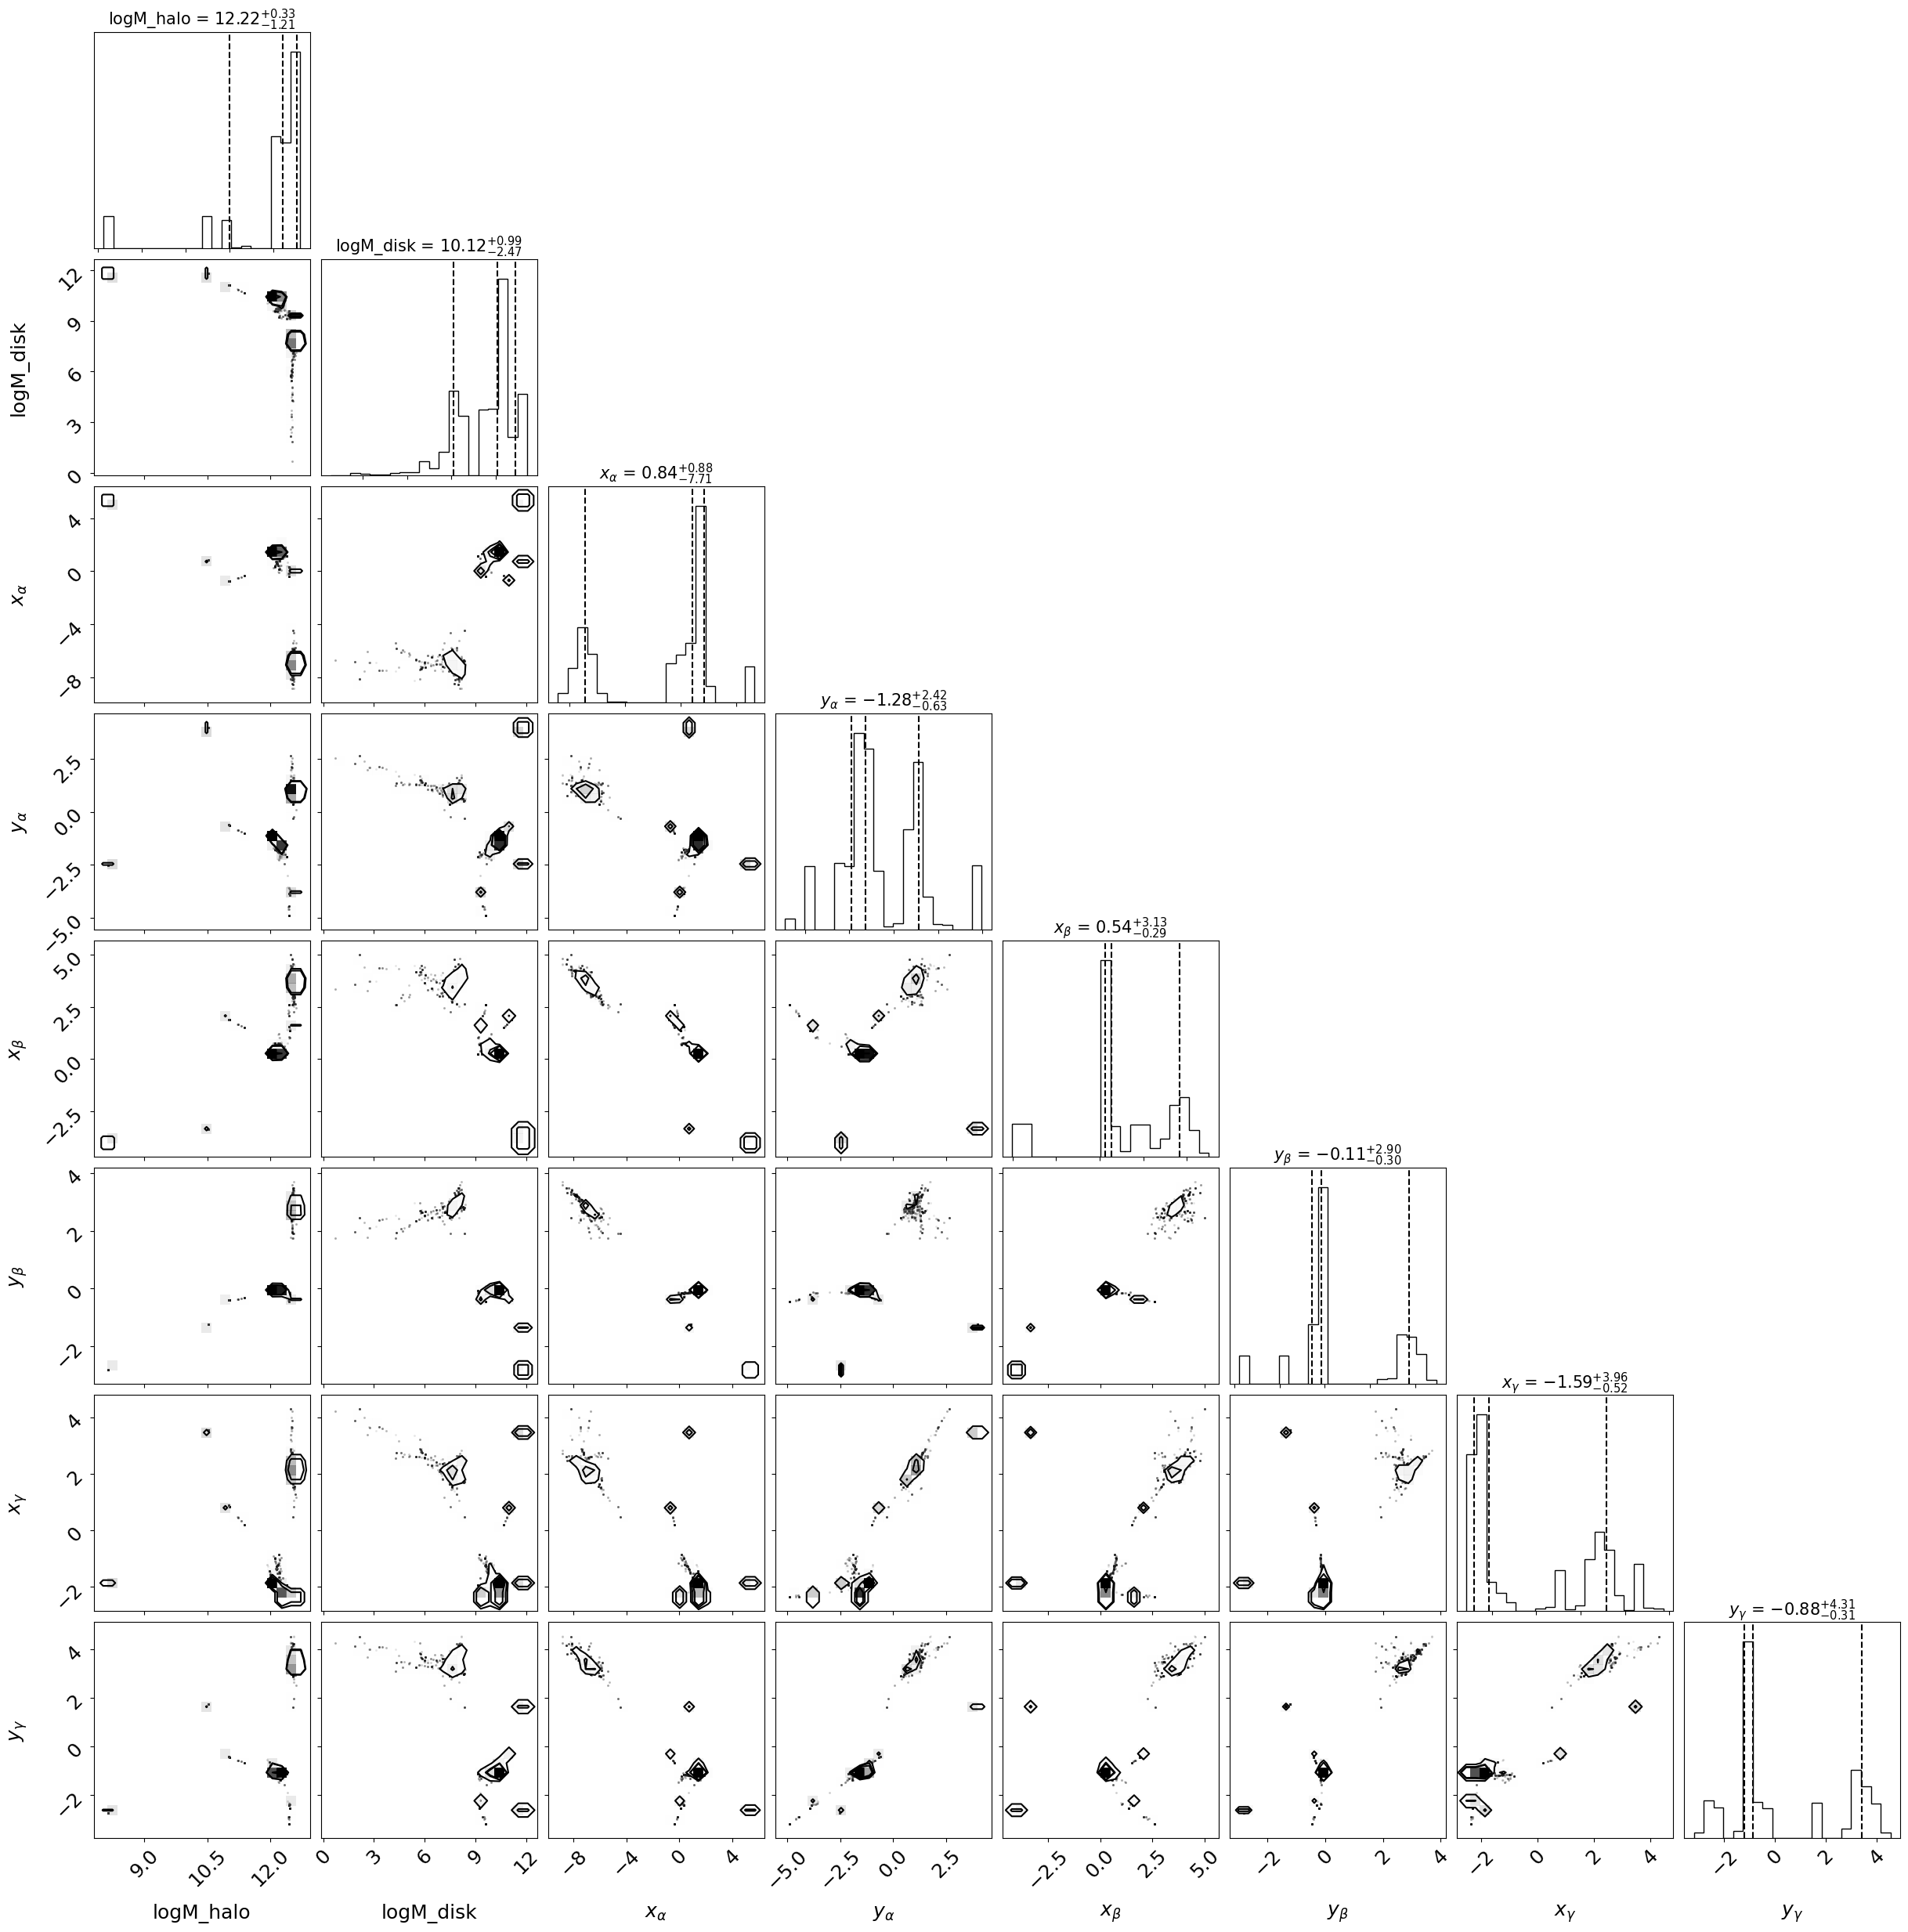

In [18]:
import pandas as pd
import corner


param_names = ['logM_halo', 'logM_disk', r'$x_\alpha$',  r'$y_\alpha$', r'$x_\beta$', r'$y_\beta$', r'$x_\gamma$', r'$y_\gamma$']

PATH_DATA = path
with open(PATH_DATA + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

with open(PATH_DATA + '/mock_axisymmetric_disc_XY_withRot.pkl', 'rb') as f:
    mock_data = pickle.load(f)

# ground_truth = {
#         'logM_halo': gt_params['halo_params']['logM'].item(),
#         'logM_disk': gt_params['disc_params']['logM'].item(),
#         'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
#         'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
#         'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
#         r'$\alpha$': mock_data['orientation'][0],
#         r'$\beta$': mock_data['orientation'][1],
#         r'$\gamma$': mock_data['orientation'][2],
# }


data_folder = '/Users/hanyuan/Desktop/PhD_projects/SchwarMAX_data'
fig, ax = plt.subplots(8, 8, figsize=(25, 25))
samples_plot = pd.read_csv(data_folder + '/test_posterior_0206.csv').to_numpy()


# ground_truth_plot = [ground_truth[k] for k in param_names]
corner.corner(samples_plot, labels=param_names,
              show_titles=True, title_fmt='.2f', title_kwargs={"fontsize": 15},
              smooth=False, truth_color='tomato', quantiles=[0.16, 0.5, 0.84], fig=fig)

best_fit_param = np.percentile(samples_plot, 50, axis=0)
print("Best-fit parameters:")
for i, name in enumerate(param_names):
    print(f"{name}: {best_fit_param[i]:.4f}")

# fig.savefig('/data/hz420-2/SchwarMAX/plots/Mock_axisymmetric_disc_posterior_0204.png', dpi=300)
# plt.show()

/var/folders/sy/hx8cmv810rq7tfr6nkmnhg3w0000gn/T/ipykernel_17384/2802748471.py:51: RuntimeWarning: invalid value encountered in divide
  H_val = np.histogram2d(samples_plot[:,i], samples_plot[:,j], bins = [xedge, yedge], weights = df_param['log_prob'])[0] / (H)


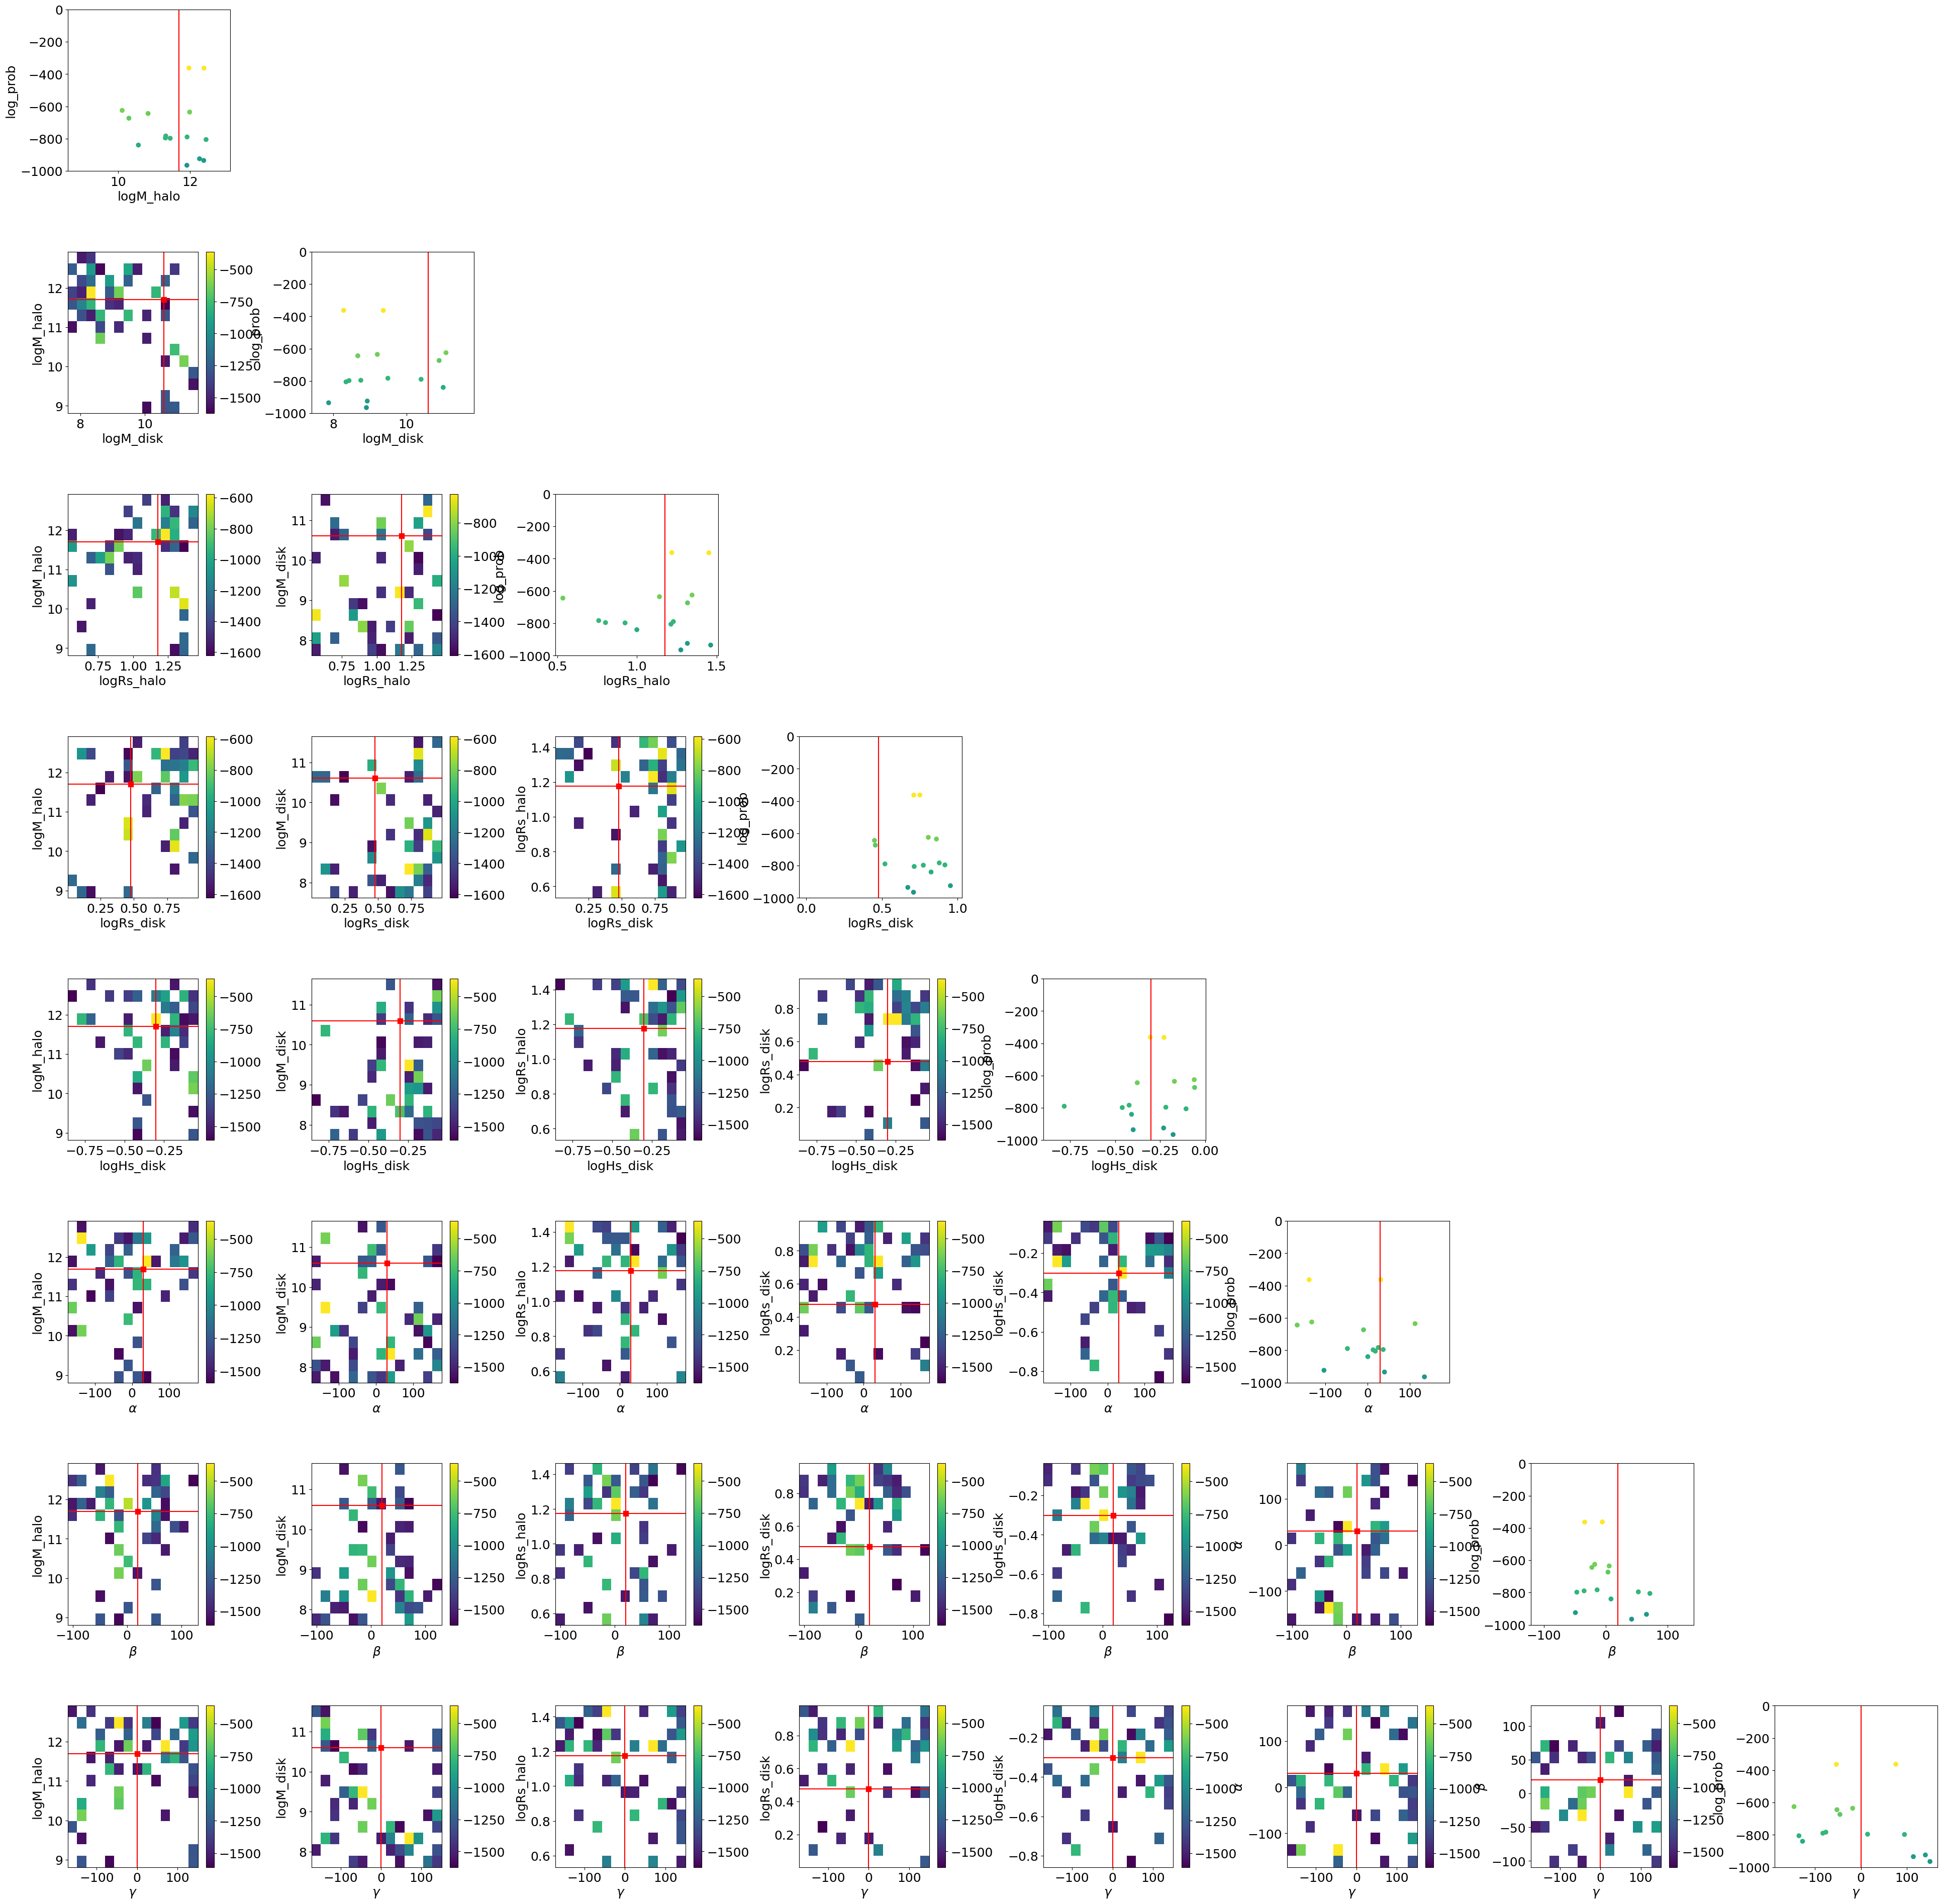

In [22]:
param_names = ['logM_halo', 'logM_disk',  'logRs_halo', 'logRs_disk', 'logHs_disk', r'$\alpha$', r'$\beta$', r'$\gamma$']

with open(path + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

with open(PATH_DATA + '/mock_axisymmetric_disc_XY_withRot.pkl', 'rb') as f:
    mock_data = pickle.load(f)

ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item(),
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
        r'$\alpha$': mock_data['orientation'][0],
        r'$\beta$': mock_data['orientation'][1],
        r'$\gamma$': mock_data['orientation'][2],
}

df_param = pd.read_csv(data_folder+'/grid_search_result_0208.csv')
df_param = df_param[df_param['log_prob'] > np.percentile(df_param['log_prob'], 95)]

logRs_halo = mapping_norm_to_scale_uniform(df_param.to_numpy()[:,2], df_param.to_numpy()[:,3], min=0.5, max=1.5)
logRs_disk = mapping_norm_to_scale_uniform(df_param.to_numpy()[:,4], df_param.to_numpy()[:,5], min=0., max=1.0)
logHs_disk = mapping_norm_to_scale_uniform(df_param.to_numpy()[:,6], df_param.to_numpy()[:,7], min=-1.0, max=0.)
alpha = np.arctan2(df_param.to_numpy()[:,3], df_param.to_numpy()[:,2])
beta = np.arctan2(df_param.to_numpy()[:,5], df_param.to_numpy()[:,4])
gamma = np.arctan2(df_param.to_numpy()[:,7], df_param.to_numpy()[:,6])

samples_plot = np.zeros((df_param.shape[0], len(param_names)))
samples_plot[:,0] = df_param['logM_halo'].to_numpy()
samples_plot[:,1] = df_param['logM_disk'].to_numpy()
samples_plot[:,2] = logRs_halo
samples_plot[:,3] = logRs_disk
samples_plot[:,4] = logHs_disk
samples_plot[:,5] = alpha * 180/np.pi
samples_plot[:,6] = beta * 180/np.pi
samples_plot[:,7] = gamma * 180/np.pi

fig, ax = plt.subplots(len(param_names), len(param_names), figsize = (6* len(param_names), 6* len(param_names)),
                       gridspec_kw={'hspace': 0.5, 'wspace': 0.5})

for j in range (len(param_names)):
  for i in range (len(param_names)):

    if i>j:
      xedge = np.linspace(np.amin(samples_plot[:,i]), np.amax(samples_plot[:,i]), 15)
      yedge = np.linspace(np.amin(samples_plot[:,j]), np.amax(samples_plot[:,j]), 15)
      xmid, ymid = (xedge[1:]+xedge[:-1])/2, (yedge[1:]+yedge[:-1])/2
      H, xedge, yedge = np.histogram2d(samples_plot[:,i], samples_plot[:,j], bins = [xedge, yedge])
      H_val = np.histogram2d(samples_plot[:,i], samples_plot[:,j], bins = [xedge, yedge], weights = df_param['log_prob'])[0] / (H)
      # cb = ax[i,j].scatter(df_param[param_names[i]], df_param[param_names[j]], c=df_param['log_prob'], cmap='viridis',vmin=-3e3)
      cb = ax[i,j].pcolormesh(xedge, yedge, H_val.T, cmap='viridis', )
      # ax[i,j].contour(xmid, ymid, H_val.T, levels = [-3000,-2000,-1000,-500])
      ax[i,j].set_xlabel(param_names[i])
      ax[i,j].set_ylabel(param_names[j])
      ax[i,j].axvline(x=ground_truth[param_names[i]], color='red')
      ax[i,j].axhline(y=ground_truth[param_names[j]], color='red')
      ax[i,j].scatter(ground_truth[param_names[i]], ground_truth[param_names[j]], color='red', marker='s', s=50)
      fig.colorbar(cb, ax = ax[i,j])

    elif i<j:
      ax[i,j].set_axis_off()

    else:
      ax[i,j].scatter(samples_plot[:,i], df_param['log_prob'], c=df_param['log_prob'], cmap='viridis')
      ax[i,j].set_xlabel(param_names[i])
      ax[i,j].set_ylabel('log_prob')
      ax[i,j].axvline(x=ground_truth[param_names[i]], color='red')
      ax[i,j].set(ylim=[-1e3, 0])

/var/folders/sy/hx8cmv810rq7tfr6nkmnhg3w0000gn/T/ipykernel_17384/1714210382.py:44: RuntimeWarning: invalid value encountered in divide
  H_val = np.histogram2d(samples_plot[:,j], samples_plot[:,i], bins = [xedge, yedge], weights = df_param['log_prob'])[0] / (H)


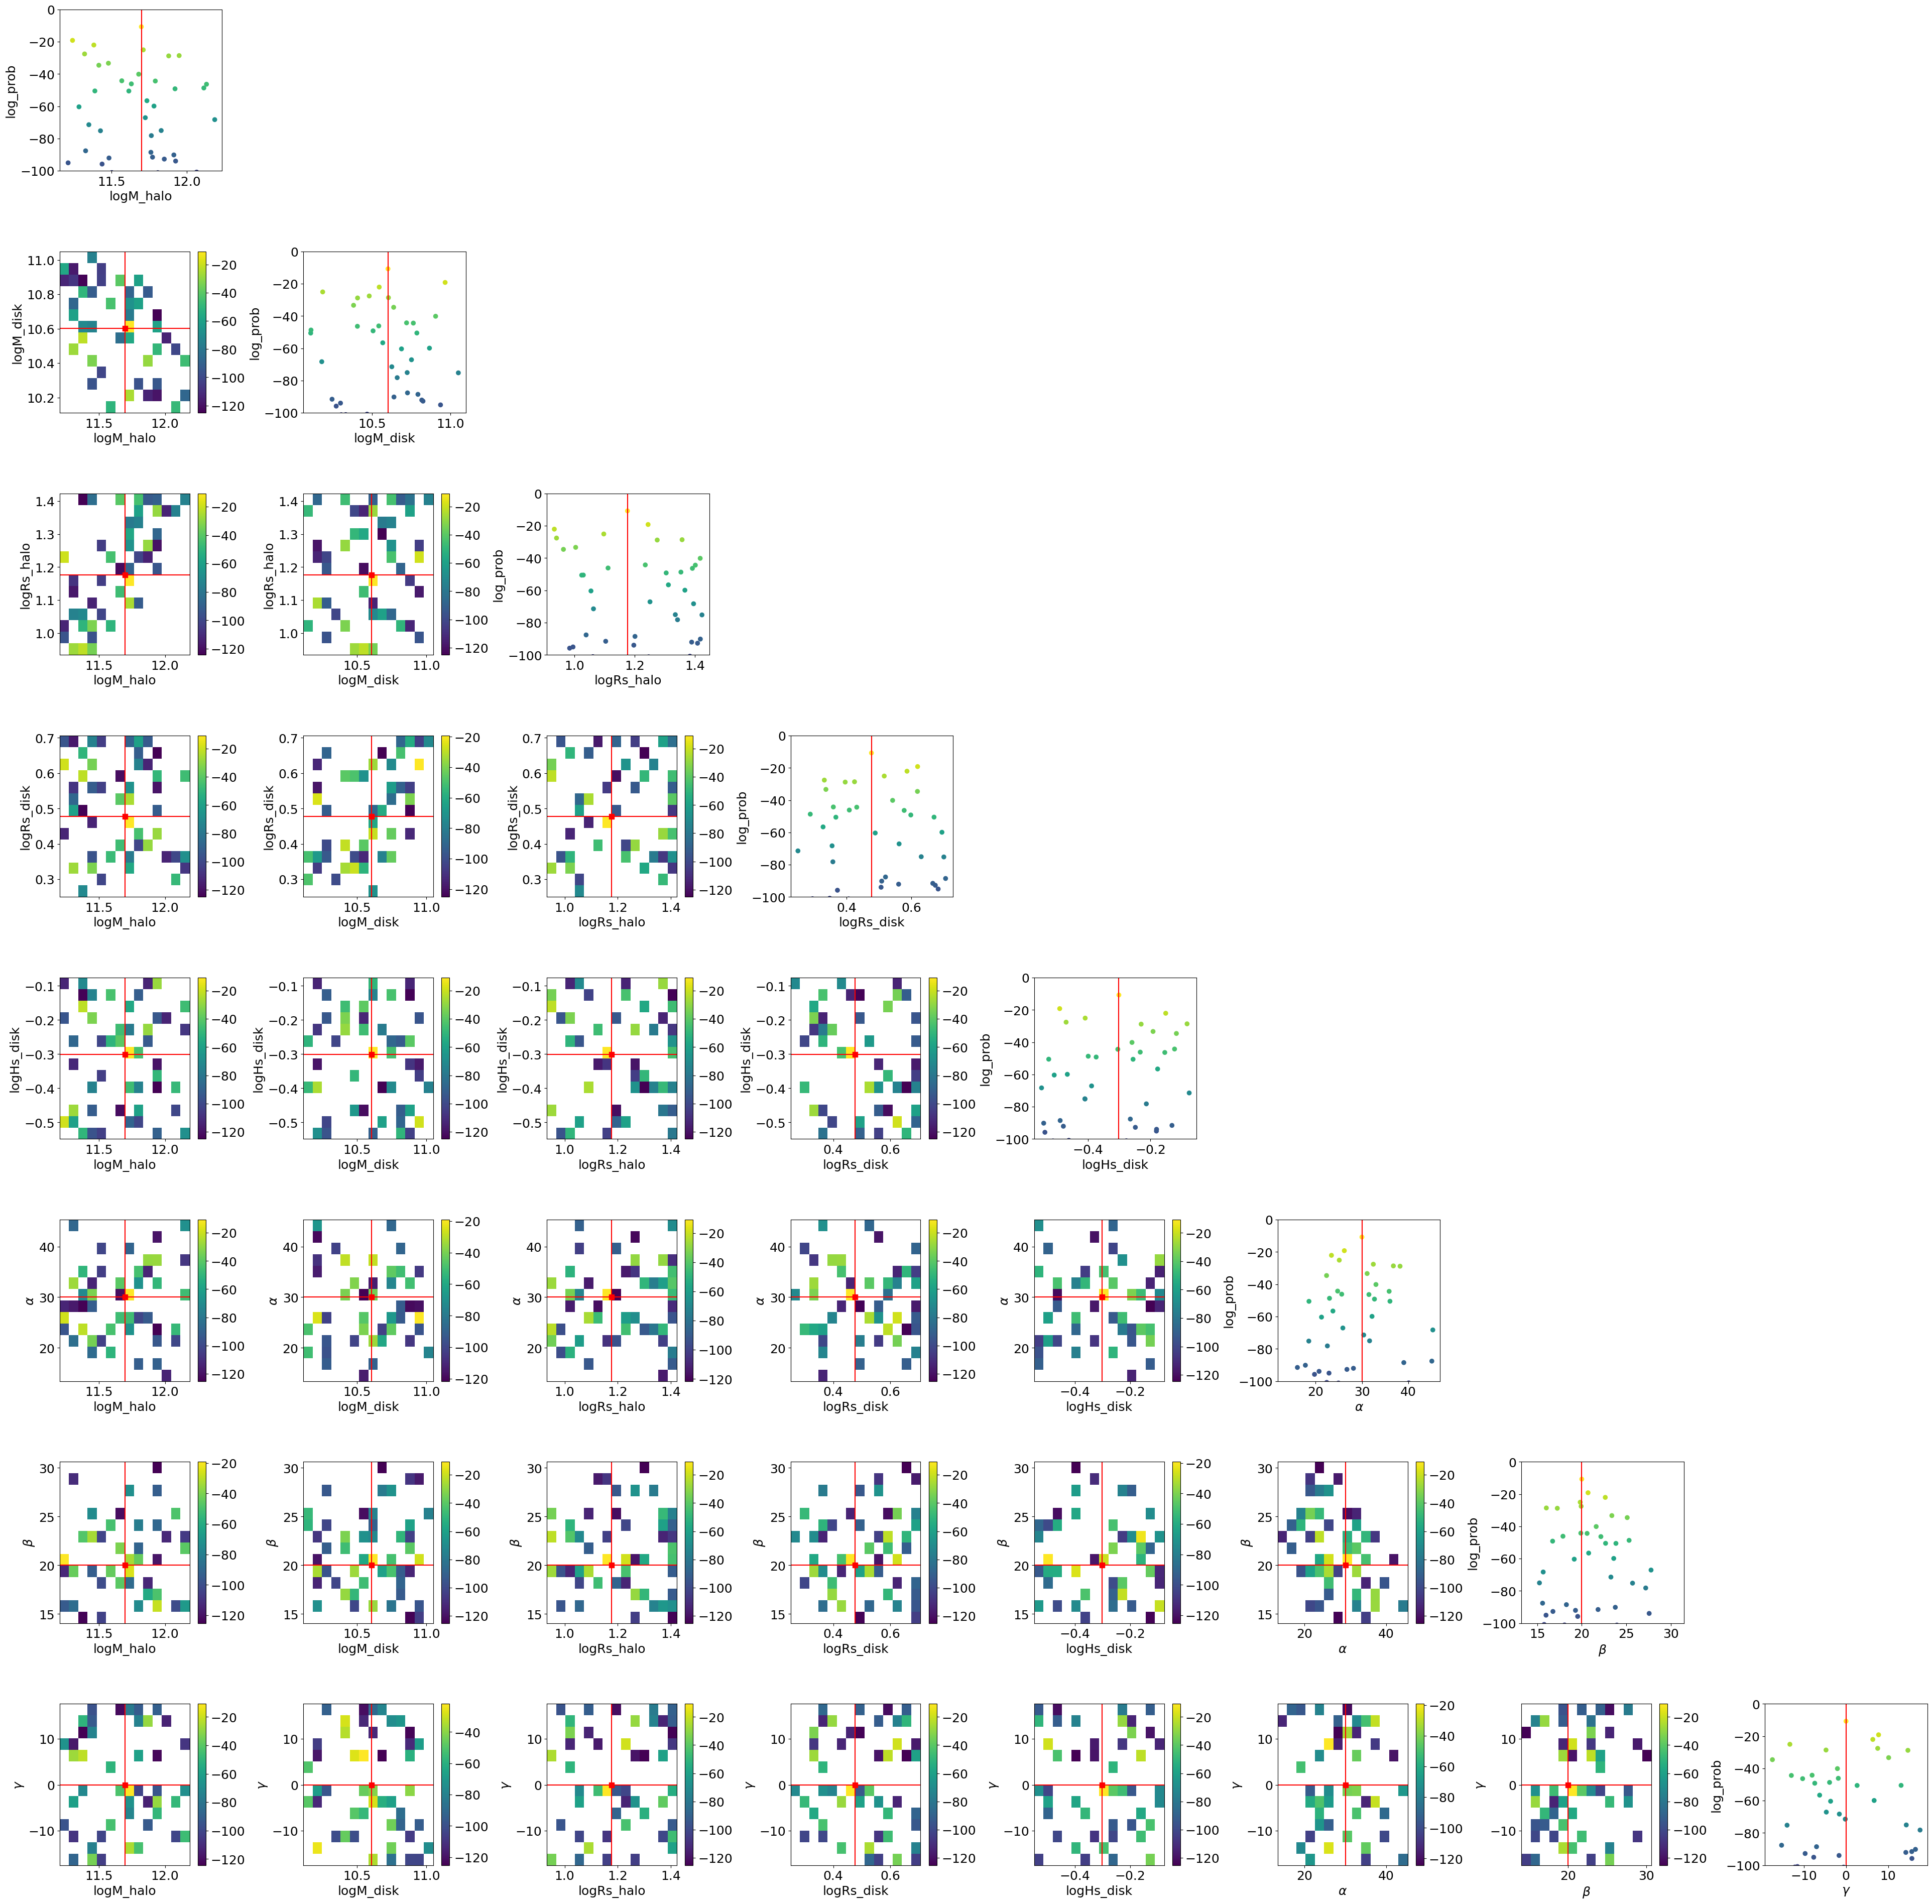

In [94]:
param_names = ['logM_halo', 'logM_disk',  'logRs_halo', 'logRs_disk', 'logHs_disk', r'$\alpha$', r'$\beta$', r'$\gamma$']

with open(path + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

with open(PATH_DATA + '/mock_axisymmetric_disc_XY_withRot.pkl', 'rb') as f:
    mock_data = pickle.load(f)

ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item(),
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
        r'$\alpha$': mock_data['orientation'][0],
        r'$\beta$': mock_data['orientation'][1],
        r'$\gamma$': mock_data['orientation'][2],
}

df_param = pd.read_csv(data_folder+'/grid_search_result_0211.csv')
df_param = df_param[df_param['log_prob'] > np.percentile(df_param['log_prob'], 95)]

samples_plot = np.zeros((df_param.shape[0], len(param_names)))
samples_plot[:,0] = df_param['logM_halo'].to_numpy()
samples_plot[:,1] = df_param['logM_disk'].to_numpy()
samples_plot[:,2] = df_param['logRs_halo']
samples_plot[:,3] = df_param['logRs_disk']
samples_plot[:,4] = df_param['logHs_disk']
samples_plot[:,5] = df_param['alpha'] * 180/np.pi
samples_plot[:,6] = df_param['beta'] * 180/np.pi
samples_plot[:,7] = df_param['gamma'] * 180/np.pi

fig, ax = plt.subplots(len(param_names), len(param_names), figsize = (6* len(param_names), 6* len(param_names)),
                       gridspec_kw={'hspace': 0.5, 'wspace': 0.5})

for j in range (len(param_names)):
  for i in range (len(param_names)):

    if i>j:
      xedge = np.linspace(np.amin(samples_plot[:,j]), np.amax(samples_plot[:,j]), 15)
      yedge = np.linspace(np.amin(samples_plot[:,i]), np.amax(samples_plot[:,i]), 15)
      xmid, ymid = (xedge[1:]+xedge[:-1])/2, (yedge[1:]+yedge[:-1])/2
      H, xedge, yedge = np.histogram2d(samples_plot[:,j], samples_plot[:,i], bins = [xedge, yedge])
      H_val = np.histogram2d(samples_plot[:,j], samples_plot[:,i], bins = [xedge, yedge], weights = df_param['log_prob'])[0] / (H)
      # cb = ax[i,j].scatter(df_param[param_names[i]], df_param[param_names[j]], c=df_param['log_prob'], cmap='viridis',vmin=-3e3)
      cb = ax[i,j].pcolormesh(xedge, yedge, H_val.T, cmap='viridis', )
      # ax[i,j].contour(xmid, ymid, H_val.T, levels = [-3000,-2000,-1000,-500])
      ax[i,j].set_xlabel(param_names[j])
      ax[i,j].set_ylabel(param_names[i])
      ax[i,j].axvline(x=ground_truth[param_names[j]], color='red')
      ax[i,j].axhline(y=ground_truth[param_names[i]], color='red')
      ax[i,j].scatter(ground_truth[param_names[j]], ground_truth[param_names[i]], color='red', marker='s', s=50)
      fig.colorbar(cb, ax = ax[i,j])

    elif i<j:
      ax[i,j].set_axis_off()

    else:
      ax[i,j].scatter(samples_plot[:,i], df_param['log_prob'], c=df_param['log_prob'], cmap='viridis')
      ax[i,j].set_xlabel(param_names[i])
      ax[i,j].set_ylabel('log_prob')
      ax[i,j].axvline(x=ground_truth[param_names[i]], color='red')
      ax[i,j].set(ylim=[-1e2, 0])

In [56]:
d_all.shape

(307,)

In [70]:
(np.fabs(df_param['alpha'].to_numpy()-ground_truth[r'$\alpha$'] * np.pi/180)<0.05).sum()

np.int64(16)

In [82]:
df_param = pd.read_csv(data_folder+'/grid_search_result_0209.csv')

d_param = np.zeros((df_param.shape[0], len(param_names)))
d_param[:,0] = df_param['logM_halo'].to_numpy() - ground_truth['logM_halo']
d_param[:,1] = df_param['logM_disk'].to_numpy() - ground_truth['logM_disk']
d_param[:,2] = df_param['logRs_halo'].to_numpy() - ground_truth['logRs_halo']
d_param[:,3] = df_param['logRs_disk'].to_numpy() - ground_truth['logRs_disk']
d_param[:,4] = df_param['logHs_disk'].to_numpy() - ground_truth['logHs_disk']
d_param[:,5] = ((df_param['alpha']) - (ground_truth[r'$\alpha$'] * np.pi/180)) * 5
d_param[:,6] = ((df_param['beta']) - (ground_truth[r'$\beta$'] * np.pi/180)) * 5
d_param[:,7] = ((df_param['gamma']) - (ground_truth[r'$\gamma$'] * np.pi/180)) * 5

d_all = np.sqrt(np.sum(d_param**2, axis=1))
best_idx = np.argmin(d_all)
print("Best-fit parameters:")
# for i, name in enumerate(param_names):
    # print(f"{name}: {samples_plot[best_idx, i]:.4f}")
print('logM_halo:', df_param['logM_halo'].iloc[best_idx])
print('logM_disk:', df_param['logM_disk'].iloc[best_idx])
print('logRs_halo:', df_param['logRs_halo'].iloc[best_idx])
print('logRs_disk:', df_param['logRs_disk'].iloc[best_idx])
print('logHs_disk:', df_param['logHs_disk'].iloc[best_idx])
print('alpha (deg):', df_param['alpha'].iloc[best_idx])
print('beta (deg):', df_param['beta'].iloc[best_idx])
print('gamma (deg):', df_param['gamma'].iloc[best_idx])

Best-fit parameters:
logM_halo: 11.59350125433602
logM_disk: 12.418466241327964
logRs_halo: 2.1409350633621216
logRs_disk: 0.7388400137424469
logHs_disk: -0.1330612599849701
alpha (deg): 0.5276893910326605
beta (deg): 0.2822524649709579
gamma (deg): -0.3558835427894687


In [35]:
with open(data_folder + '/test_posterior_WholeChain_0210.pkl', 'rb') as f:
    posterior = pickle.load(f)
posterior.shape

(300, 16, 8)

(0.0, 100.0)

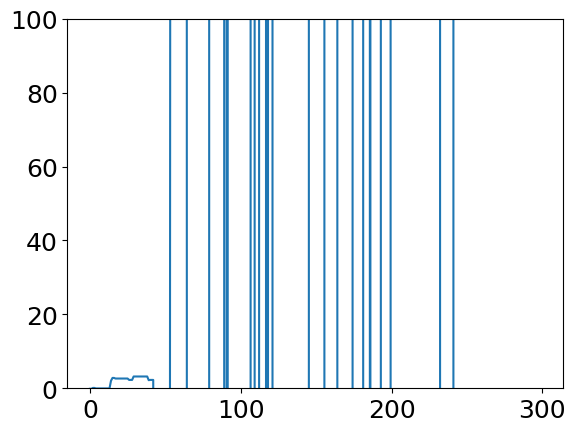

In [41]:
plt.plot(posterior[:,1,3])
plt.ylim(0,100)